In [ ]:
import pandas as pd
df= pd.read_csv('/content/heart_disease_cleaned.csv')

In [ ]:
df.head(10)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


In [ ]:
df['num'].unique()

array([0, 2, 1, 3, 4])

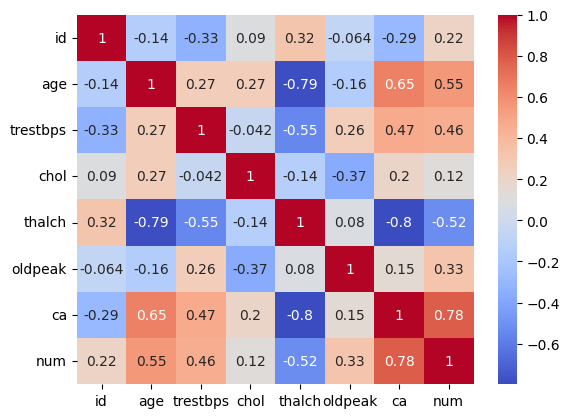

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
subset = df.head(10).select_dtypes(include="number")
sns.heatmap(subset.corr(), annot=True, cmap="coolwarm")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['fbs']=le.fit_transform(df['fbs'])
df['exang']=le.fit_transform(df['exang'])



In [ ]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
df['cp'] = oe.fit_transform(df[['cp']])
df['restecg'] = oe.fit_transform(df[['restecg']])
df['slope'] = oe.fit_transform(df[['slope']])
df['thal'] = oe.fit_transform(df[['thal']])

In [ ]:
df.columns

Index(['id', 'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
       'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [ ]:
import numpy as np
def wisker (col):
  q1,q3=np.percentile(col,[25,75])
  iqr=q3-q1
  lw=q1-(1.5*iqr)
  uw=q3+(1.5*iqr)
  return lw,uw

for i in ['id', 'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
       'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'
        ]:
       lw,uw=wisker(df[i])
       df[i]=np.where(df[i]<lw,lw,df[i])
       df[i]=np.where(df[i]>uw,uw,df[i])

In [ ]:
df.head(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,1,Cleveland,3.0,145.0,233.0,1,0.0,150.0,0,2.3,0.0,0.0,0.0,0
1,2,67,1,Cleveland,0.0,160.0,286.0,0,0.0,108.0,1,1.5,1.0,3.0,1.0,2
2,3,67,1,Cleveland,0.0,120.0,229.0,0,0.0,129.0,1,2.6,1.0,2.0,2.0,1
3,4,37,1,Cleveland,2.0,130.0,250.0,0,1.0,187.0,0,3.5,0.0,0.0,1.0,0
4,5,41,0,Cleveland,1.0,130.0,204.0,0,0.0,172.0,0,1.4,2.0,0.0,1.0,0


In [ ]:
df=df.drop('dataset',axis=1)

In [ ]:
df.head(5)

,id,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,1,3.0,145.0,233.0,1,0.0,150.0,0,2.3,0.0,0.0,0.0,0
1,2,67,1,0.0,160.0,286.0,0,0.0,108.0,1,1.5,1.0,3.0,1.0,2
2,3,67,1,0.0,120.0,229.0,0,0.0,129.0,1,2.6,1.0,2.0,2.0,1
3,4,37,1,2.0,130.0,250.0,0,1.0,187.0,0,3.5,0.0,0.0,1.0,0
4,5,41,0,1.0,130.0,204.0,0,0.0,172.0,0,1.4,2.0,0.0,1.0,0


In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop('num', axis=1)
y = df['num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale — LR needs this
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Model — class_weight built in
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_sc, y_train)
print(classification_report(y_test, lr.predict(X_test_sc)))

              precision    recall  f1-score   support

           0       0.86      0.83      0.84        82
           1       0.54      0.40      0.46        53
           2       0.20      0.14      0.16        22
           3       0.31      0.43      0.36        21
           4       0.18      0.67      0.29         6

    accuracy                           0.57       184
   macro avg       0.42      0.49      0.42       184
weighted avg       0.60      0.57      0.58       184



In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from scipy.stats import loguniform

# Define the parameter distribution for Logistic Regression
param_dist_lr = {
    'C': loguniform(0.001, 100), # Inverse of regularization strength; must be a positive float
    'penalty': ['l1', 'l2'],     # Specify the norm (L1 or L2) used in the penalization
    'solver': ['liblinear']      # Solver that supports both l1 and l2 penalties
}

# Initialize Logistic Regression with class_weight='balanced' and increased max_iter
lr_base = LogisticRegression(
    class_weight='balanced',
    max_iter=1000, # Increased iterations for convergence
    random_state=42
)

# Set up RandomizedSearchCV for Logistic Regression
random_search_lr = RandomizedSearchCV(
    estimator=lr_base,
    param_distributions=param_dist_lr,
    n_iter=50, # Number of parameter settings that are sampled
    scoring='f1_macro', # Using f1_macro for multi-class classification and imbalance
    cv=5, # 5-fold cross-validation
    verbose=1,
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# Fit RandomizedSearchCV to the scaled training data
random_search_lr.fit(X_train_sc, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=LogisticRegression(class_weight='balanced',
                                                max_iter=1000,
                                                random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d8515238590>,
                                        'penalty': ['l1', 'l2'],
                                        'solver': ['liblinear']},
                   random_state=42, scoring='f1_macro', verbose=1)

In [ ]:
from sklearn.metrics import classification_report

print("Best parameters found by RandomizedSearchCV for Logistic Regression:")
display(random_search_lr.best_params_)

# Get the best Logistic Regression model
best_lr_model = random_search_lr.best_estimator_

# Make predictions on the scaled test data
y_pred_lr_tuned = best_lr_model.predict(X_test_sc)

# Evaluate the model's performance
print("\nClassification Report for Tuned Logistic Regression:")
print(classification_report(y_test, y_pred_lr_tuned))

Best parameters found by RandomizedSearchCV for Logistic Regression:


{'C': np.float64(0.16949768237884735), 'penalty': 'l1', 'solver': 'liblinear'}


Classification Report for Tuned Logistic Regression:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86        82
           1       0.53      0.45      0.49        53
           2       0.25      0.14      0.18        22
           3       0.34      0.48      0.40        21
           4       0.21      0.50      0.30         6

    accuracy                           0.60       184
   macro avg       0.44      0.49      0.44       184
weighted avg       0.61      0.60      0.60       184



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define the parameter distribution for RandomizedSearchCV for RandomForest
param_dist_rf = {
    'n_estimators': randint(100, 1000),      # Number of trees in the forest
    'max_features': ['sqrt', 'log2'],       # Number of features to consider when looking for the best split
    'max_depth': randint(10, 100),          # Maximum number of levels in tree
    'min_samples_split': randint(2, 20),    # Minimum number of samples required to split an internal node
    'min_samples_leaf': randint(1, 10),     # Minimum number of samples required to be at a leaf node
    'criterion': ['gini', 'entropy']        # Function to measure the quality of a split
}

# Initialize Random Forest Classifier with class_weight='balanced'
rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

# Set up RandomizedSearchCV for Random Forest
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=50, # Number of parameter settings that are sampled
    scoring='f1_macro', # Using f1_macro for multi-class classification and imbalance
    cv=5, # 5-fold cross-validation
    verbose=1,
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# Fit RandomizedSearchCV to the scaled training data
# We'll use X_train_sc and y_train as SMOTE has shown good results with tree-based models too.
random_search_rf.fit(X_train_sc, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d851517b080>,
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d8515179d90>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d851517aa50>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d851511b200>},
                   random_state=42, scoring='f1_macro', verbose=1)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, mean_absolute_error, confusion_matrix

print("Best parameters found by RandomizedSearchCV for Random Forest:")
display(random_search_rf.best_params_)

# Get the best Random Forest model
best_rf_model = random_search_rf.best_estimator_

# Make predictions on the scaled test data
y_pred_rf_tuned = best_rf_model.predict(X_test_sc)

# Evaluate the model's performance
accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
con_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

print(f"\nAccuracy for Tuned Random Forest: {accuracy_rf_tuned:.4f}")
print(f"Mean Absolute Error for Tuned Random Forest: {mae_rf_tuned:.4f}")
print("Classification Report for Tuned Random Forest:")
print(classification_report(y_test, y_pred_rf_tuned))
print("Confusion Matrix for Tuned Random Forest:")
display(con_rf_tuned)

Best parameters found by RandomizedSearchCV for Random Forest:


{'criterion': 'entropy',
 'max_depth': 13,
 'max_features': 'log2',
 'min_samples_leaf': 5,
 'min_samples_split': 8,
 'n_estimators': 848}


Accuracy for Tuned Random Forest: 0.6685
Mean Absolute Error for Tuned Random Forest: 0.4620
Classification Report for Tuned Random Forest:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90        82
           1       0.73      0.57      0.64        53
           2       0.31      0.36      0.33        22
           3       0.41      0.62      0.49        21
           4       0.00      0.00      0.00         6

    accuracy                           0.67       184
   macro avg       0.47      0.49      0.47       184
weighted avg       0.71      0.67      0.68       184

Confusion Matrix for Tuned Random Forest:


array([[72,  6,  3,  1,  0],
       [ 4, 30, 11,  6,  2],
       [ 2,  2,  8,  8,  2],
       [ 0,  2,  3, 13,  3],
       [ 0,  1,  1,  4,  0]])